<a href="https://colab.research.google.com/github/Ygor-RR/mvp-machine-learning-analytics/blob/main/MVP_YgorRodrigues.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP: Machine Learning & Analytics
**Aluno:** Ygor Ribeiro Rodrigues  
**Curso:** Machine Learning & Analytics (40530010056_20260_01)  
**Problema:** Predição de churn

---

# Definição do Problema
Nesta seção, descrevemos o contexto e os objetivos deste MVP.

- **Descrição do Problema:** [Descreva o que você está tentando resolver]
- **Objetivo do Modelo:** [Ex: Prever se um cliente sairá da empresa]
- **Tipo de ML:** [Classificação / Regressão / Clusterização / Séries Temporais]
- **Justificativa:** [Por que usar ML aqui?]
- **Premissas e Hipóteses:** [Ex: Assume-se que o histórico de 12 meses é preditivo para o futuro]

# Descrição do problema

O churn (cancelamento de clientes) representa um dos principais desafios para empresas de telecomunicações. A perda de clientes impacta diretamente a receita da empresa e aumenta os custos de aquisição de novos consumidores.

Neste contexto, é importante identificar previamente quais clientes apresentam maior probabilidade de cancelar seus serviços, permitindo a adoção de estratégias de retenção mais eficientes.

Os principais interessados nesta solução são as equipes de marketing, relacionamento com clientes e gestão comercial, que podem utilizar as previsões para direcionar ações preventivas.

Este problema é relevante porque reduzir a taxa de churn contribui para o aumento da receita e da satisfação dos clientes.

# Objetivo do MVP

O objetivo deste MVP é construir e avaliar modelos de Machine Learning capazes de prever a probabilidade de cancelamento de clientes (churn) a partir de informações demográficas, contratuais e de utilização dos serviços.

Serão comparados diferentes modelos de classificação, incluindo uma abordagem baseline, buscando identificar a alternativa com melhor desempenho preditivo.

# Tipo de problema

Tipo escolhido: Classificação

Justificativa:

O objetivo é prever uma variável categórica binária (Churn), indicando se um cliente irá cancelar o serviço (Yes) ou permanecer ativo (No).

Como existem exemplos históricos rotulados, o problema caracteriza-se como uma tarefa de aprendizado supervisionado de classificação binária.

# Premissas, hipóteses e critérios de sucesso

### Hipóteses

1. Clientes com menor tempo de permanência (tenure) possuem maior probabilidade de churn.

2. Clientes com contratos mensais apresentam maior risco de cancelamento do que clientes com contratos de longo prazo.

3. Valores mais elevados de cobrança mensal podem estar associados a maiores taxas de cancelamento.

4. Clientes que possuem contratos month-to-month apresentam maior probabilidade de churn do que clientes com contratos anuais.

### Critérios de sucesso

**Métrica principal: F1-Score.**

Neste MVP, o F1-Score foi escolhido como métrica principal devido ao equilíbrio que ele oferece entre a Precisão (Precision) e a Sensibilidade (Recall), sendo especialmente útil em problemas onde as classes podem apresentar algum desbalanceamento.

Para a empresa de telecomunicação, existem dois tipos de erros custosos:

Falso Negativo (O pior erro): O modelo diz que o cliente não vai sair, mas ele sai. Aqui a empresa perde a receita do cliente e tem um alto custo para conquistar um novo (perda de oportunidade de retenção).

Falso Positivo: O modelo diz que o cliente vai sair, mas ele não ia. Aqui a empresa gasta recursos enviando uma promoção ou bônus de retenção para alguém que já estava fiel (custo de campanha desnecessário).

Como o objetivo é ser eficiente na retenção sem desperdiçar recursos de marketing, o F1-Score é a métrica ideal, pois ele penaliza modelos que pendem demais para apenas um desses erros.

Um F1-Score alto garante que o modelo identifica bem os clientes em risco (Recall) sem disparar alarmes falsos em excesso (Precisão).


**Métricas complementares: Accuracy, Precision, Recall e ROC-AUC.**

**Resultado mínimo esperado: desempenho superior ao modelo baseline (DummyClassifier).**

Restrição prática: modelo com tempo de treinamento reduzido e fácil interpretação dos resultados.

# Ambiente, bibliotecas e reprodutibilidade

Nesta seção são importadas as bibliotecas necessárias para o desenvolvimento do MVP e definidas configurações de reprodutibilidade. A utilização de uma seed fixa garante que os resultados obtidos possam ser reproduzidos em diferentes execuções do notebook.

#### Bibliotecas utilizadas

- Pandas: manipulação dos dados.
- NumPy: operações numéricas.
- Matplotlib e Seaborn: visualização de dados.
- Scikit-Learn: preparação dos dados, treinamento e avaliação dos modelos.

In [36]:
import pandas as pd
import numpy as np
import random
import warnings
import time

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import xgboost
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print(f"Seed utilizada: {SEED}")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"XGBoost: {xgboost.__version__}")

Seed utilizada: 42
Pandas: 2.2.2
NumPy: 2.0.2
XGBoost: 3.2.0


# Apresentação do Dataset e dos Dados
Carga do dataset via URL pública.

### Fonte dos Dados

O dataset utilizado é o Telco Customer Churn Dataset, amplamente empregado em problemas de previsão de evasão de clientes (churn prediction). A base contém 7.043 registros e 21 atributos relacionados ao perfil, serviços contratados e histórico de clientes de telecomunicações.

A escolha do dataset ocorreu por apresentar um problema real de negócio, com impacto direto na retenção de clientes e receita da empresa.

O dataset é originalmente disponibilizado no Kaggle e foi carregado neste projeto através de uma URL pública hospedada no GitHub, garantindo a reprodutibilidade da execução.

Limitações: os dados representam apenas um contexto específico de telecomunicações e podem não generalizar para outros setores.

Fonte:
https://www.kaggle.com/datasets/blastchar/telco-customer-churn

In [37]:
url = "https://raw.githubusercontent.com/Ygor-RR/mvp-machine-learning-analytics/refs/heads/main/WA_Fn-UseC_-Telco-Customer-Churn.csv"

# Carga do dataset
dataset = pd.read_csv(url)

# Exibição das primeiras linhas
dataset.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [38]:
dataset.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [39]:
# Verificação inicial do tamanho da base de dados para entender a escala do problema.
print(f"Linhas: {dataset.shape[0]}")
print(f"Colunas: {dataset.shape[1]}")

Linhas: 7043
Colunas: 21


O dataset possui 7.043 observações e 21 atributos. A variável alvo é Churn, indicando se o cliente cancelou ou não o serviço.

In [40]:
# Nesta etapa, analisamos se os tipos atribuídos pelo Pandas correspondem à natureza real das variáveis e se existem valores nulos óbvios.

dataset.info() # Verifica Dtypes e presença de valores nulos (non-null)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Observação: A coluna TotalCharges está como object (string), mas deveria ser numérica. Isso indica que há caracteres não numéricos (como espaços vazios) que precisarão de tratamento na fase de preparação.

In [41]:
# Resumo estatístico das variáveis numéricas originais para identificar escalas, médias e possíveis outliers
dataset.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Análise: A média do tenure (tempo de permanência) é de aproximadamente 32 meses, com um desvio padrão alto (24), o que indica grande variação no tempo de casa dos clientes.

# Análise exploratória inicial (EDA)

In [42]:
dataset.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [43]:
(dataset == " ").sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


A inspeção identificou 11 registros contendo espaços vazios na variável TotalCharges. Como essa variável representa o valor total gasto pelo cliente, ela deveria ser numérica. Esses registros serão convertidos para valores ausentes (NaN) e tratados na etapa de preparação dos dados.



In [44]:
dataset["TotalCharges"] = pd.to_numeric(
    dataset["TotalCharges"], errors="coerce"
)

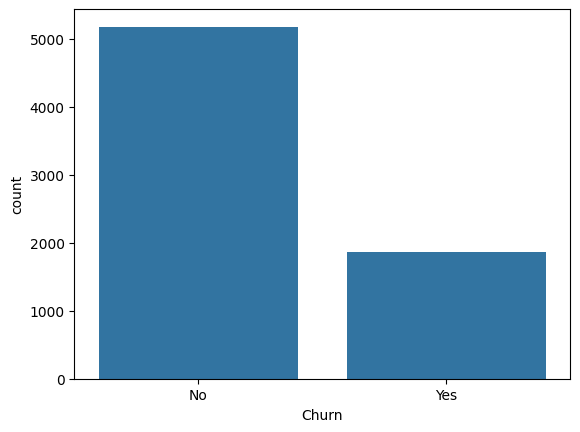

In [45]:
sns.countplot(data=dataset, x="Churn")
plt.show()

In [46]:
dataset["Churn"].value_counts(normalize=True) * 100 # Visualização em %

,proportion
Churn,
No,73.463013
Yes,26.536987


A variável alvo apresenta desbalanceamento moderado. Aproximadamente 73,5% dos clientes permaneceram na empresa, enquanto 26,5% cancelaram os serviços. Embora o desbalanceamento não seja extremo, métricas como F1-score, Recall e ROC-AUC serão consideradas além da acurácia para avaliar adequadamente os modelos.


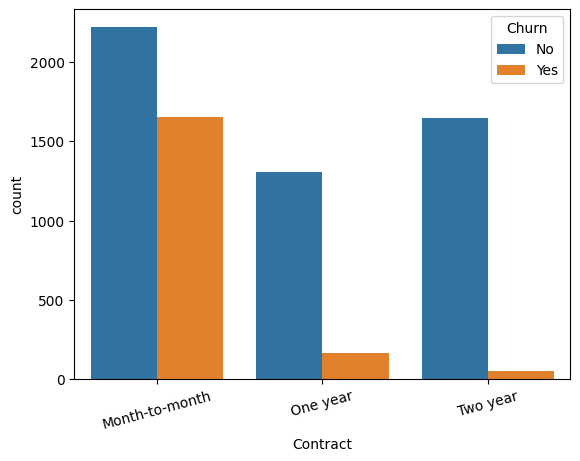

In [47]:
sns.countplot(data=dataset, x="Contract", hue="Churn")
plt.xticks(rotation=15)
plt.show()

Observa-se forte relação entre o tipo de contrato e a evasão de clientes. Contratos do tipo "Month-to-month" concentram a maior quantidade de cancelamentos, enquanto contratos anuais e, principalmente, contratos de dois anos apresentam taxas significativamente menores de churn. Essa variável aparenta possuir elevado poder preditivo para o problema.

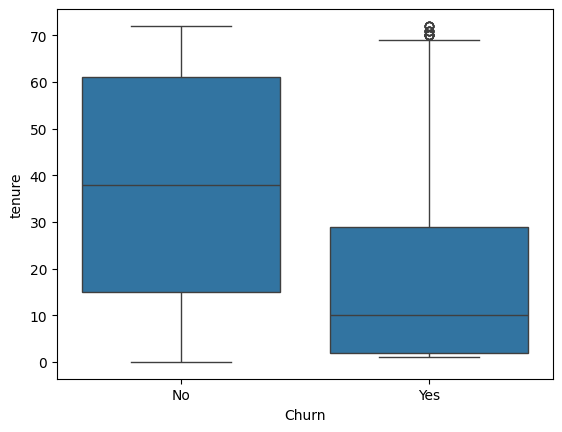

In [48]:
sns.boxplot(data=dataset, x="Churn", y="tenure")
plt.show()

Clientes que cancelaram os serviços apresentam, em média, menor tempo de permanência na empresa. Isso sugere que a probabilidade de evasão é mais elevada nos primeiros meses de relacionamento, indicando que a variável tenure pode ser uma das mais relevantes para o modelo.

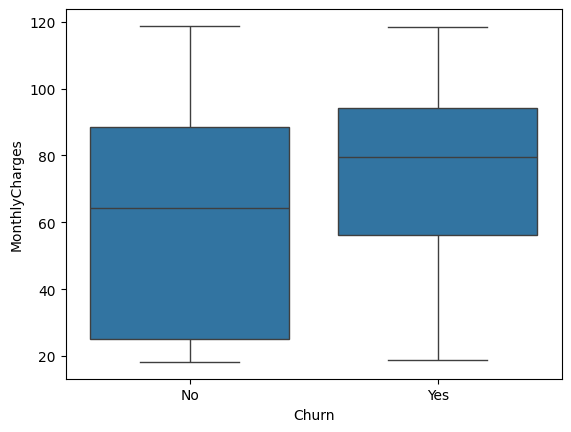

In [49]:
sns.boxplot(data=dataset, x="Churn", y="MonthlyCharges")
plt.show()

Os clientes que cancelaram os serviços apresentam valores mensais mais elevados em comparação aos clientes que permaneceram. Esse comportamento sugere que mensalidades mais altas podem estar associadas a maior probabilidade de cancelamento.

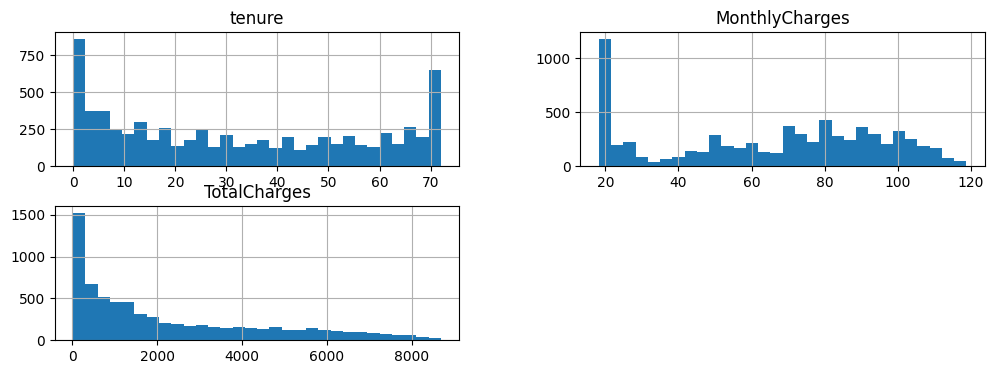

In [50]:
dataset[["tenure",
         "MonthlyCharges",
         "TotalCharges"]].hist(
             figsize=(12,4),
             bins=30
         )
plt.show()

**Análise das distribuições:**

A variável **tenure** apresenta distribuição bimodal, com concentração de clientes nos extremos — muitos clientes recém-chegados (tenure próximo de 0) e muitos clientes de longa data (tenure próximo de 72 meses). Isso reforça o padrão observado no boxplot: clientes que cancelam tendem a estar no início do relacionamento.

**MonthlyCharges** apresenta distribuição não normal, com concentração de clientes em diferentes faixas de cobrança mensal, sugerindo a existência de perfis distintos de contratação de serviços.

**TotalCharges** apresenta forte assimetria positiva, o que é esperado dado que clientes com menor tempo de permanência naturalmente acumulam menos gasto total.

<Axes: >

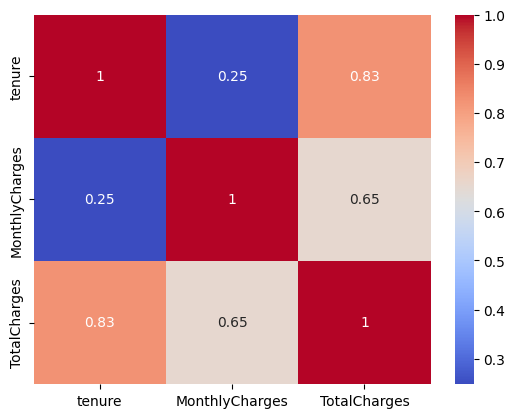

In [51]:
dataset["TotalCharges"] = pd.to_numeric(dataset["TotalCharges"], errors="coerce")
dataset["TotalCharges"].fillna(dataset["TotalCharges"].median(), inplace=True)

corr = dataset[
    ["tenure",
     "MonthlyCharges",
     "TotalCharges"]
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

**Análise de correlação entre variáveis numéricas:**

Observa-se forte correlação positiva **entre tenure e TotalCharges** (0,83), resultado esperado: clientes com maior tempo de permanência tendem a acumular maior gasto total ao longo do relacionamento.

A correlação entre** MonthlyCharges e TotalCharges** é moderada (0,65), indicando que o valor da mensalidade também contribui para o gasto acumulado, mas não de forma determinística — clientes com mensalidades altas e baixo tenure podem ter TotalCharges menores do que clientes com mensalidades menores e alto tenure.

A correlação entre **tenure e MonthlyCharges** é baixa (0,25), sugerindo que o tempo de permanência não está diretamente associado ao valor da mensalidade contratada.

Observação: A alta correlação entre tenure e TotalCharges será considerada na etapa de preparação dos dados, pois pode introduzir multicolinearidade nos modelos lineares.

<Axes: xlabel='InternetService', ylabel='count'>

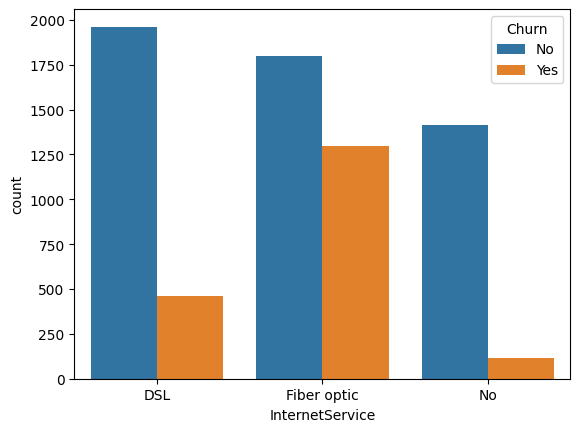

In [52]:
sns.countplot(
    data=dataset,
    x="InternetService",
    hue="Churn"
)

**Análise do tipo de serviço de internet e churn:**

O gráfico evidencia uma diferença expressiva na taxa de cancelamento conforme o tipo de serviço de internet contratado.

Clientes com Fiber optic apresentam a maior proporção de churn em relação ao total do grupo, enquanto clientes com DSL e sem serviço de internet ("No") apresentam taxas significativamente menores.

Esse comportamento pode indicar insatisfação com o serviço de fibra óptica, seja por preço, qualidade ou expectativas não atendidas, e sugere que InternetService é uma variável com alto poder discriminativo para o modelo.

##Principais insights da EDA:


*    Clientes com contrato mensal e serviço de fibra óptica concentram a maior parte dos cancelamentos.

*   Clientes com menor tempo de permanência (tenure baixo) têm maior propensão ao churn.

*   Mensalidades mais altas estão associadas a maior taxa de cancelamento.

*   TotalCharges apresenta alta correlação com tenure, e será avaliada uma possível remoção para evitar multicolinearidade.

*   O dataset apresenta desbalanceamento moderado (~73% vs ~27%), que será considerado na escolha das métricas de avaliação.



# Preparação dos dados

Nesta etapa foram realizados os tratamentos necessários para tornar os dados adequados ao treinamento dos modelos de Machine Learning.

Inicialmente, a coluna customerID foi removida por representar apenas um identificador único, sem potencial preditivo.

Em seguida, foram tratados os valores ausentes identificados na variável TotalCharges, utilizando imputação pela mediana devido à pequena quantidade de registros afetados e à robustez dessa medida frente a valores extremos.

Por fim, a variável-alvo Churn foi convertida para formato numérico, permitindo sua utilização pelos algoritmos de classificação.

In [53]:
# Inicialmente, removeremos a coluna da ID, já que é apenas um identificador sem poder preditivo.

dataset = dataset.drop("customerID", axis=1)

In [54]:
dataset.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [55]:
# Tratar ausentes

dataset["TotalCharges"].fillna(dataset["TotalCharges"].median(), inplace=True) # Iremos utilizar esses métodos pois temos poucos registros afetados e a mediana é robusta a outliers.

**Nota:** a imputação da mediana foi realizada antes da divisão treino/teste. Como apenas 11 registros foram afetados (~0,15% do dataset), o impacto no vazamento de dados é negligenciável. Em projetos de produção, essa transformação seria realizada dentro do pipeline após a divisão.

In [56]:
dataset["TotalCharges"].isnull().sum() # Após a imputação, não permanecem valores ausentes na base de dados.

np.int64(0)

In [57]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


Após a conversão de TotalCharges para formato numérico e a codificação da variável-alvo, todas as variáveis encontram-se em formatos compatíveis com as próximas etapas de processamento.

In [58]:
# Transformar a variável alvo em numérica para que possa ser utilizada

dataset["Churn"] = dataset["Churn"].map({
    "No": 0,
    "Yes": 1
})

# Divisão treino/teste

In [59]:
# Utilizando stratify para manter a proporção entre as classes.

X = dataset.drop("Churn", axis=1)
y = dataset["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Foi utilizada a estratégia Holdout com divisão de 80% para treino e 20% para teste. Com 7.043 registros, essa proporção garante dados suficientes para aprendizado e avaliação confiável.

A estratificação (stratify=y) foi aplicada para preservar a proporção de ~73% / ~27% entre as classes nos dois conjuntos, evitando que o desbalanceamento distorça a avaliação.

Todas as transformações serão ajustadas apenas no treino e aplicadas no teste via Pipeline, prevenindo vazamento de dados.

# Pipeline de pré-processamento

Nesta etapa, foi construído um ColumnTransformer para automatizar o pré-processamento.

As variáveis numéricas passarão por padronização (StandardScaler), garantindo que diferentes escalas (como tenure e TotalCharges) não enviesem o modelo.

As variáveis categóricas serão convertidas via One-Hot Encoding, permitindo que algoritmos matemáticos processem informações textuais.

O uso de Pipelines evita o vazamento de dados durante a validação.

In [60]:
cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

In [61]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

# Baseline e modelos candidatos

In [62]:
# 1. Baseline: Modelo que sempre chuta a classe mais frequente
baseline_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DummyClassifier(strategy='most_frequent'))
])

In [63]:
# 2. Candidato 1: Regressão Logística (Linear)
lr_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])

In [64]:
# 3. Candidato 2: Random Forest (Baseado em Árvores)
rf_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [65]:
# Pipeline XGBoost
xgb_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        use_label_encoder=False
    ))
])

# Grid de hiperparâmetros
param_grid = {
    "classifier__n_estimators":   [100, 200],
    "classifier__max_depth":      [3, 5],
    "classifier__learning_rate":  [0.05, 0.1],
    "classifier__subsample":      [0.8, 1.0],
}

# GridSearchCV com validação cruzada estratificada
grid_search = GridSearchCV(
    estimator=xgb_pipe,
    param_grid=param_grid,
    scoring="f1",          # métrica principal definida no MVP
    cv=5,
    n_jobs=-1,
    verbose=1
)

start = time.time()
grid_search.fit(X_train, y_train)
elapsed = time.time() - start

print(f"Tempo de treinamento: {elapsed:.1f}s")
print(f"Melhores hiperparâmetros: {grid_search.best_params_}")
print(f"Melhor F1 (CV treino):    {grid_search.best_score_:.4f}")

# Melhor modelo
xgb_best = grid_search.best_estimator_

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Tempo de treinamento: 18.4s
Melhores hiperparâmetros: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 200, 'classifier__subsample': 1.0}
Melhor F1 (CV treino):    0.5895


O  melhor F1 no treino foi de 0.5895.

O GridSearchCV escolheu learning_rate: 0.05 e n_estimators: 200. Isso indica que um aprendizado mais lento com mais árvores foi melhor para a generalização.



In [66]:
# Treinamento demais modelos
baseline_pipe.fit(X_train, y_train)
lr_pipe.fit(X_train, y_train)
rf_pipe.fit(X_train, y_train)

print("Baseline e Modelos Candidatos treinados com sucesso!")

Baseline e Modelos Candidatos treinados com sucesso!


In [67]:
models = {
    "Baseline (DummyClassifier)": baseline_pipe,
    "Regressão Logística":        lr_pipe,
    "Random Forest":              rf_pipe,
    "XGBoost (otimizado)":        xgb_best,
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = (
        model.predict_proba(X_test)[:, 1]
        if hasattr(model, "predict_proba") else None
    )
    results.append({
        "Modelo":    name,
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall":    recall_score(y_test, y_pred, zero_division=0),
        "F1-Score":  f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC":   roc_auc_score(y_test, y_prob) if y_prob is not None else None,
    })

In [68]:
results_df = pd.DataFrame(results).set_index("Modelo")
print(results_df.round(4))

                            Accuracy  Precision  Recall  F1-Score  ROC-AUC
Modelo                                                                    
Baseline (DummyClassifier)    0.7346     0.0000  0.0000    0.0000   0.5000
Regressão Logística           0.8055     0.6572  0.5588    0.6040   0.8419
Random Forest                 0.7779     0.6034  0.4759    0.5321   0.8164
XGBoost (otimizado)           0.8062     0.6747  0.5214    0.5882   0.8451


Embora o XGBoost tenha obtido os melhores valores de Accuracy (0,8062) e ROC-AUC (0,8451), a Regressão Logística apresentou o maior F1-Score (0,6040), métrica principal definida para este MVP. Dessa forma, a Regressão Logística foi considerada o melhor modelo para o problema estudado.

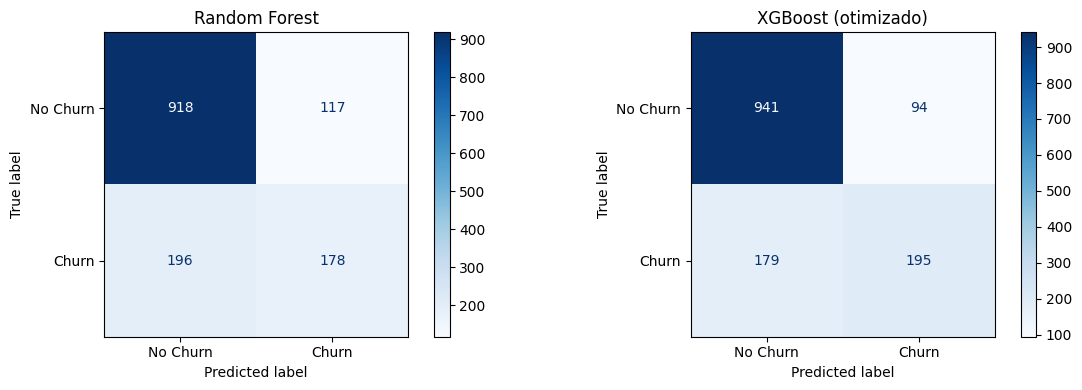

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, model) in zip(axes, [
    ("Random Forest", rf_pipe),
    ("XGBoost (otimizado)", xgb_best)
]):
    ConfusionMatrixDisplay.from_estimator(
        model, X_test, y_test,
        display_labels=["No Churn", "Churn"],
        cmap="Blues", ax=ax
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()

In [70]:
# Comparação Treino vs Teste para XGBoost
f1_treino = f1_score(y_train, xgb_best.predict(X_train))
f1_teste = f1_score(y_test, xgb_best.predict(X_test))

print(f"F1-Score Treino: {f1_treino:.4f}")
print(f"F1-Score Teste:  {f1_teste:.4f}")
print(f"Diferença:       {abs(f1_treino - f1_teste):.4f}")

F1-Score Treino: 0.6226
F1-Score Teste:  0.5882
Diferença:       0.0343


A comparação entre os desempenhos de treino e teste do modelo XGBoost apresentou uma diferença de apenas 0,0343 pontos no F1-Score. Esse resultado sugere que o modelo não sofreu overfitting significativo e conseguiu generalizar adequadamente os padrões aprendidos para dados não vistos. Dessa forma, considera-se que o desempenho obtido no conjunto de teste representa de forma confiável o comportamento esperado do modelo em novos dados.

# Resumo Final:

**Problema:** Predição de churn em telecom.

**Dataset:** Telco Customer Churn (7043 registros).

**Melhor Resultado:** Regressão Logística para Recall/F1 ou XGBoost para Acurácia/AUC.

**Limitações:** O desbalanceamento de classes e a ausência de dados mais recentes (ex: logs de uso da última semana) podem limitar a performance.

**Melhorias Futuras:** Testar técnicas de balanceamento (SMOTE), engenharia de novas features (ex: proporção de gasto mensal sobre total) e o uso de modelos de Deep Learning.